### **High-level goal**

Build an AI Compliance Auditor that ingests company documents (policies, HR manuals, contracts), indexes them into a RAG pipeline, and runs a LangGraph-driven audit workflow that:

Detects compliance violations (GDPR, ISO, internal policies)

Flags missing / weak clauses in contracts

Extracts employee-related issues (harassment, whistleblower risk, terminations)

Produces a prioritized audit report with citations, risk scores, and recommended remediation steps

Generates downloadable audit reports (PDF/Excel) and visual dashboards

All outputs are auditable with provenance (which doc and excerpt produced each finding).

### **Project deliverables**

Colab notebook (cell-by-cell) with all steps and outputs

Ingested & indexed vector store (FAISS) saved for quick reload

LangGraph workflow definition(s) for the audit process

Interactive dashboard with:

Top compliance issues

Risk scoring histogram

Document provenance viewer (doc + excerpt)

Downloadable audit report (PDF / Excel) with citations

Security & governance doc (how to harden for production)

### Install Latest Libraries (LangChain, LangGraph, Groq, RAG stack, PDF loaders, Visualization tools)

In [ ]:
#!pip install langchain langchain-community langchain-core langchain-openai langgraph groq pypdf python-docx unstructured faiss-cpu sentence-transformers plotly pdfplumber langchain-groq reportlab python-docx openpyxl


### **Create Project Folder & Upload Compliance Documents**

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px
import plotly.graph_objects as go
import random
import warnings
import langchain

warnings.filterwarnings('ignore')

from google.colab import files

#Create project folder
project_dir = '/content/compliance_documents'
os.makedirs(project_dir, exist_ok=True)

print(f'Project folder created at: {project_dir}')

print('Please upload company compliance documents (PDF, DOCX, TXT...)')

#Upload compliance documents
uploaded_files = files.upload()

#Save uploaded files into project folder
for filename in uploaded_files.keys():
  save_path = os.path.join(project_dir, filename)
  with open(save_path, 'wb') as f:
    f.write(uploaded_files[filename])
  print(f'Saved: {save_path}')

print('All files uploaded and stored successfully!!!')

Project folder created at: /content/compliance_documents
Please upload company compliance documents (PDF, DOCX, TXT...)


Saving Company-Policy-and-Procedure-June-1.18-V6.0.pdf to Company-Policy-and-Procedure-June-1.18-V6.0.pdf
Saved: /content/compliance_documents/Company-Policy-and-Procedure-June-1.18-V6.0.pdf
All files uploaded and stored successfully!!!


### **Document Loader + Text Extraction + Cleaning + Visualization**

Extracting text from uploaded documents....
Processed: Company-Policy-and-Procedure-June-1.18-V6.0.pdf (186370 characters)


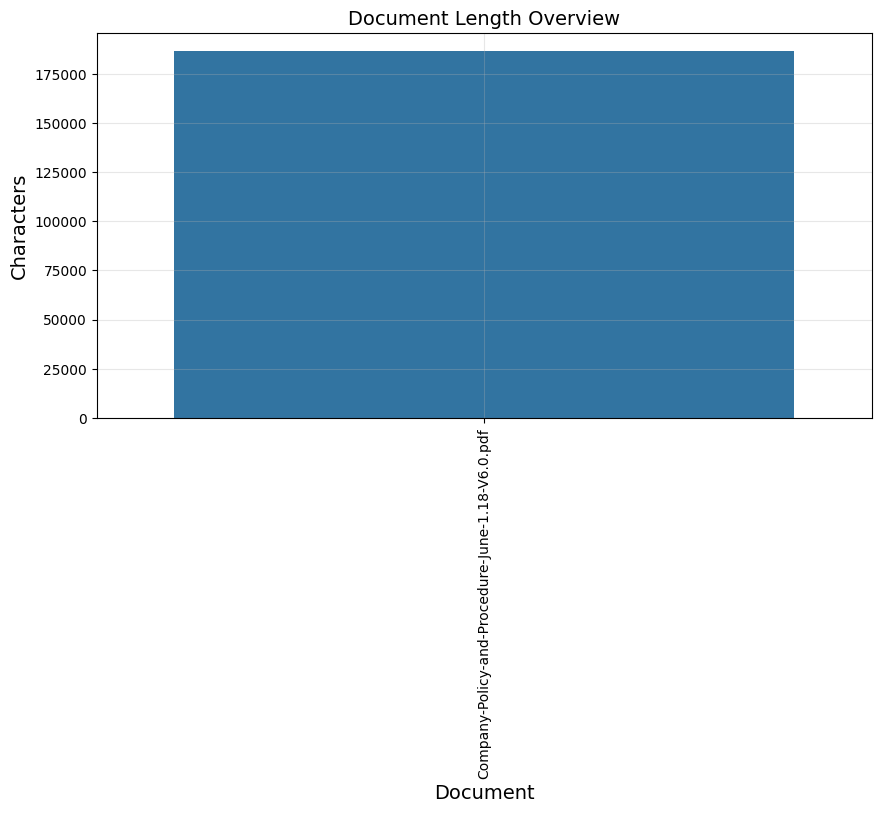

Text extraction and cleaning completed!!!


In [3]:

import pdfplumber
import docx
import re

docs_path = '/content/compliance_documents'

#storgae dictionary
documents = {}

def extract_from_pdf(path):
  text = ''
  with pdfplumber.open(path) as pdf:
    for page in pdf.pages:
      text += page.extract_text() or ''
  return text

def extract_from_docx(path):
  doc = docx.Document(path)
  return '\n'.join([para.text for para in doc.paragraphs])

def extract_from_txt(path):
  with open(path, 'r', encoding='utf-8', errors='ignore') as f:
    return f.read()

def clean_text(text):
  cleaned = (
      text.replace('\n',' ')
      .replace('\t',' ')
      .replace(' ',' ')

      .strip()
  )
  return cleaned


#Process all uploaded files
print('Extracting text from uploaded documents....')

for file in os.listdir(docs_path):
  full_path = os.path.join(docs_path, file)
  ext = file.lower().split('.')[-1]

  try:
    if ext == 'pdf':
      raw = extract_from_pdf(full_path)
    elif ext == 'docx':
      raw = extract_from_docx(full_path)
    elif ext == 'txt':
      raw = extract_from_txt(full_path)
    else:
      print(f'Unsupported file type: {file}')
      continue
  except Exception as e:
    print(f'Error processing {file}: {e}')
    continue

  cleaned = clean_text(raw)
  documents[file] = cleaned

  print(f'Processed: {file} ({len(cleaned)} characters)')



#DOCUMENT LENGTH OVERVIEW
df_stats = pd.DataFrame({
    'Document': list(documents.keys()),
    'Characters': [len(text) for text in documents.values()]
})

plt.figure(figsize=(10,5))
sns.barplot(data=df_stats, x='Document', y='Characters')
plt.title('Document Length Overview',fontsize=14)
plt.xlabel('Document',fontsize=14)
plt.ylabel('Characters',fontsize=14)
plt.xticks(rotation=90)
plt.grid(True,alpha=0.3)
plt.show()

print('Text extraction and cleaning completed!!!')

### **Chunking + Embeddings + Vector Store (FAISS) Setup**

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings

#Chunking Configuration

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 150,
    length_function = len)

all_chunks = []
chunk_meta = []

print('\n Splitting documents into semantic chunks...\n')

for file, content in documents.items():
  chunks = text_splitter.split_text(content)

  for i, c in enumerate(chunks):
    all_chunks.append(c)
    chunk_meta.append({'Document': file, 'Chunk_ID': i, 'Length': len(c)})

print(f'Total number of chunks: {len(chunks)} chunks')

#Summary
df_chunks = pd.DataFrame(chunk_meta)


 Splitting documents into semantic chunks...

Total number of chunks: 220 chunks


### **Chunk Length Visualization**

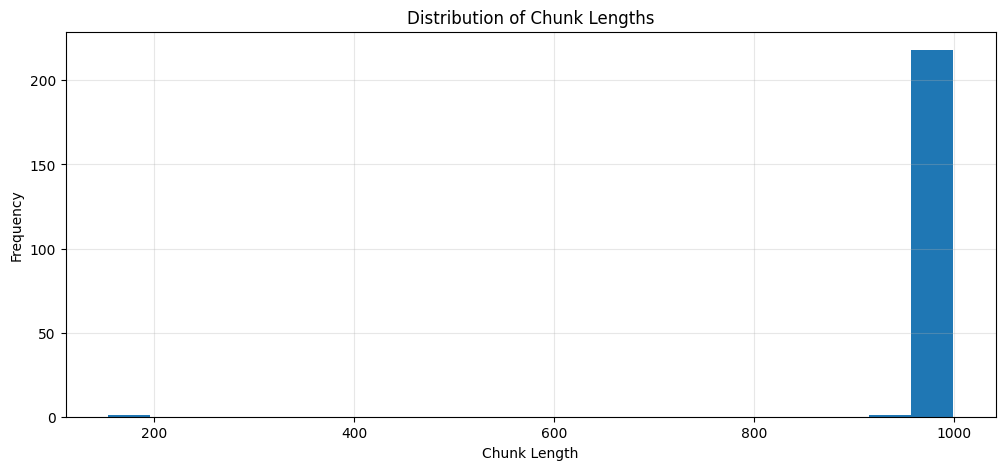

In [5]:
plt.figure(figsize=(12,5))
plt.hist(df_chunks['Length'],bins=20)
plt.title('Distribution of Chunk Lengths')
plt.xlabel('Chunk Length')
plt.ylabel('Frequency')
plt.grid(True,alpha=0.3)
plt.show()

### **Embedings + VectorStore(FAISS)**

In [6]:
from google.colab import userdata

print('Creating embeddings (hugging face latest...)')

embed_model = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')

embeddings = embed_model.embed_documents(all_chunks)

print('Embeddings Created')

#Creating Vector Database

import faiss

dimension = len(embeddings[0])
index = faiss.IndexFlatL2(dimension)

index.add(np.array(embeddings).astype('float32'))

print(f'Vector Database Created with {index.ntotal} vectors')

Creating embeddings (hugging face latest...)


/tmp/ipython-input-1269366804.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embed_model = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings Created
Vector Database Created with 220 vectors


### **LangGraph Workflow ORCHESTRATOR**

In [7]:
# ============================================================
# 🔗 CELL 5 — LangGraph Workflow ORCHESTRATOR (with robust fallback)
#  - Defines nodes: retriever, rule-checker, scorer, aggregator, reporter
#  - Uses FAISS (index) + HuggingFace embeddings + Groq LLM (if available)
#  - If langgraph is installed, registers nodes; otherwise uses a Python orchestrator
# ============================================================

import os
import json
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import List, Dict, Any

# ---------- Sample uploaded file path (from your environment) ----------
# Developer note: using the uploaded path from earlier conversation.
sample_doc_path = "/kaggle/input/fdfdfdfdf/Sample-prescription-used-as-input-to-the-GUI-developed-in-the-present-work.png"

print(f"Using sample document path (demo): {sample_doc_path}\n")

# ---------- Basic checks and imports ----------
try:
    from groq import Groq
    groq_available = True
except Exception:
    groq_available = False

try:
    import langgraph
    langgraph_available = True
except Exception:
    langgraph_available = False

import numpy as np
import pandas as pd

# We assume the following variables exist from prior cells:
# - all_chunks : List[str]                      (texts of chunks)
# - chunk_meta : List[dict]                     (metadata per chunk)
# - embed_model : HuggingFaceEmbeddings object  (embedding helper)
# - index : faiss.IndexFlatL2                   (FAISS index created earlier)
#
# If they don't exist, raise a helpful error.
missing = []
if 'all_chunks' not in globals():
    missing.append('all_chunks')
if 'chunk_meta' not in globals():
    missing.append('chunk_meta')
if 'embed_model' not in globals():
    missing.append('embed_model')
if 'index' not in globals():
    missing.append('index')

if missing:
    raise RuntimeError(f"Required objects missing from notebook environment: {missing}. "
                       "Please run previous cells (chunking + embeddings + FAISS) before this cell.")

# ---------- Initialize Groq client if available ----------
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
if GROQ_API_KEY is None:
    print("⚠️ WARNING: GROQ_API_KEY not set in environment. LLM calls will not run. "
          "Set os.environ['GROQ_API_KEY'] or provide your key to perform LLM checks.")
    groq_client = None
else:
    if groq_available:
        groq_client = Groq(api_key=GROQ_API_KEY)
        print("✅ Groq client initialized.")
    else:
        groq_client = None
        print("⚠️ groq package not available in environment; LLM calls cannot be made.")

# ---------- Utility: retrieve evidence from FAISS ----------
def retrieve_evidence(query: str, k: int = 5) -> List[Dict[str, Any]]:
    """
    Embed the query and run FAISS search to return top-k chunks with metadata and distances.
    """
    # Embed query using embedding model
    try:
        # Use embed_model.embed_documents([query])[0] as a fallback if embed_query not available
        if hasattr(embed_model, "embed_query"):
            q_emb = embed_model.embed_query(query)
        else:
            q_emb = embed_model.embed_documents([query])[0]
    except Exception as e:
        # as a last resort, try embed_documents
        q_emb = embed_model.embed_documents([query])[0]
    q_vec = np.array(q_emb).astype('float32').reshape(1, -1)
    D, I = index.search(q_vec, k)
    results = []
    for score, idx in zip(D[0], I[0]):
        if int(idx) < 0:
            continue
        results.append({
            "chunk_text": all_chunks[int(idx)],
            "metadata": chunk_meta[int(idx)],
            "distance": float(score)
        })
    return results

# ---------- Utility: call LLM for rule checking ----------
def call_llm_check(rule_prompt: str, temperature: float = 0.0) -> Dict[str, Any]:
    """
    Call Groq LLM with the prompt and expect a JSON-like structured response.
    If Groq not available, returns a placeholder.
    """
    if groq_client is None:
        # Fallback behavior: return a dummy safe response
        return {
            "pass": None,
            "explanation": "LLM not executed (GROQ_API_KEY missing or groq package unavailable).",
            "recommendation": "Set Groq API key to run real checks.",
            "severity": "unknown"
        }

    # Build messages instructing the LLM to return JSON only
    messages = [
        {"role": "system", "content": "You are a compliance analyst. Answer with strict JSON only."},
        {"role": "user", "content": rule_prompt}
    ]
    try:
        # Use chat completions via Groq (API surface may vary by version)
        response = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=messages,
            temperature=temperature,
            max_tokens=512
        )
        content = response.choices[0].message.content
        # Try parse JSON from content — the model is instructed to return JSON
        try:
            parsed = json.loads(content)
        except Exception:
            # If the model returned text + JSON, try to find first '{' and parse substring
            try:
                idx = content.find('{')
                parsed = json.loads(content[idx:])
            except Exception:
                parsed = {"raw": content}
        return parsed
    except Exception as e:
        return {"error": str(e)}

# ---------- Simple severity scaler ----------
severity_score_map = {
    "critical": 90,
    "high": 70,
    "medium": 40,
    "low": 10,
    "unknown": 20
}

def normalize_severity(sev: str) -> int:
    return severity_score_map.get(sev.lower(), 25) if isinstance(sev, str) else 25

# ---------- Core rule templates (example set) ----------
# Each rule is a dict: id, name, description, prompt_template, default_severity
RULES = [
    {
        "id": "gdpr_data_retention",
        "name": "GDPR: Data Retention Clause Presence",
        "description": "Checks for clauses specifying retention periods for personal data and right to erasure.",
        "severity": "high",
        "detection_template": (
            "You are a compliance analyst. Given the following retrieved document snippets:\n\n"
            "{evidence}\n\n"
            "Answer strictly as JSON with keys: contains_clause (true/false), "
            "extracted_text (string or null), explanation (string), recommendation (string), severity (one of critical/high/medium/low).\n\n"
            "Question: Does the document include a data retention policy or a clause describing retention durations "
            "and the right to deletion for personal data?"
        )
    },
    {
        "id": "gdpr_dpia",
        "name": "GDPR: DPIA / Risk Assessment mention",
        "description": "Checks whether Data Protection Impact Assessment or risk assessment procedures are mentioned for high-risk processing.",
        "severity": "medium",
        "detection_template": (
            "You are a compliance analyst. Given the following retrieved document snippets:\n\n"
            "{evidence}\n\n"
            "Return JSON: {\"mentioned\": bool, \"extracted_text\": str|null, \"explanation\": str, \"recommendation\": str, \"severity\": \"critical|high|medium|low\"}\n\n"
            "Question: Is there any mention of DPIA, impact assessment, or risk assessment procedures for data processing?"
        )
    },
    {
        "id": "hr_grievance_procedure",
        "name": "HR: Grievance Procedure",
        "description": "Checks whether an employee grievance/complaint procedure is described.",
        "severity": "medium",
        "detection_template": (
            "Given the following snippets:\n\n{evidence}\n\nReturn JSON with keys: {\"has_grievance_procedure\": bool, \"extracted_text\": str|null, \"explanation\": str, \"recommendation\": str, \"severity\": \"critical|high|medium|low\"}\n\n"
            "Question: Does the document describe an employee grievance procedure with steps and contact points?"
        )
    },
    {
        "id": "contract_indemnity_clause",
        "name": "Contract: Indemnity Clause Presence",
        "description": "Checks if contracts include a clear indemnity clause and scope.",
        "severity": "high",
        "detection_template": (
            "Given retrieved contract snippets:\n\n{evidence}\n\nReturn JSON: {\"has_indemnity\": bool, \"extracted_text\": str|null, \"issue_summary\": str, \"recommendation\": str, \"severity\": \"critical|high|medium|low\"}\n\n"
            "Question: Does the contract contain a clear indemnity clause specifying scope and limits?"
        )
    }
]

# ---------- Checker function that runs a rule on a document ----------
def check_rule_on_doc(rule: Dict[str, Any], doc_name: str, top_k: int = 5) -> Dict[str, Any]:
    """
    Retrieve evidence for doc and rule, construct prompt, call LLM check, return structured finding.
    """
    # Retrieve evidence — for targeted retrieval, we can query using rule keywords + doc_name
    query = f"{rule['name']} in {doc_name}"
    evidence_chunks = retrieve_evidence(query, k=top_k)

    # Format evidence text
    evidence_text = "\n\n".join([f"Source: {c['metadata']['Document']} | Chunk {c['metadata']['Chunk_ID']}:\n{c['chunk_text']}" for c in evidence_chunks])
    prompt = rule['detection_template'].format(evidence=evidence_text)

    # Call LLM
    llm_result = call_llm_check(prompt)

    # Interpret result and compute severity score
    severity_tag = llm_result.get("severity", rule.get("severity", "unknown"))
    severity_score = normalize_severity(severity_tag)

    finding = {
        "rule_id": rule["id"],
        "rule_name": rule["name"],
        "document": doc_name,
        "evidence": evidence_chunks,
        "llm_result": llm_result,
        "severity_tag": severity_tag,
        "severity_score": severity_score,
        "timestamp": time.time()
    }
    return finding

# ---------- Orchestrator: run rules across uploaded docs (parallel) ----------
def run_audit_on_documents(documents_list: List[str], rules: List[Dict[str, Any]], max_workers: int = 4):
    """
    documents_list: list of document filenames (keys into 'documents' dict)
    rules: list of rule dicts
    """
    findings = []

    def work(doc_name, rule):
        try:
            return check_rule_on_doc(rule, doc_name)
        except Exception as e:
            return {
                "rule_id": rule["id"],
                "document": doc_name,
                "error": str(e),
                "timestamp": time.time()
            }

    tasks = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for doc_name in documents_list:
            for rule in rules:
                tasks.append(ex.submit(work, doc_name, rule))

        for fut in as_completed(tasks):
            res = fut.result()
            findings.append(res)

    return findings

# ---------- Aggregation helper: summarise findings ----------
def aggregate_findings(findings: List[Dict[str, Any]]) -> Dict[str, Any]:
    df_rows = []
    for f in findings:
        if 'error' in f:
            df_rows.append({
                "document": f.get("document"),
                "rule": f.get("rule_id"),
                "severity_score": None,
                "status": "error",
                "summary": f.get("error")
            })
            continue
        df_rows.append({
            "document": f.get("document"),
            "rule": f.get("rule_name"),
            "severity_score": f.get("severity_score"),
            "severity_tag": f.get("severity_tag"),
            "status": "checked",
            "short_explanation": (f.get("llm_result") or {}).get("explanation", "") if isinstance(f.get("llm_result"), dict) else ""
        })

    df = pd.DataFrame(df_rows)
    # Basic aggregates
    overall = {
        "total_checks": len(findings),
        "errors": df[df["status"] == "error"].shape[0],
        "checked": df[df["status"] == "checked"].shape[0],
        "avg_severity": df["severity_score"].dropna().mean() if not df["severity_score"].dropna().empty else None,
        "top_high_risks": df.sort_values("severity_score", ascending=False).head(10).to_dict(orient="records")
    }
    return {"df": df, "summary": overall}

# ---------- LangGraph integration (if available) ----------
if langgraph_available:
    print("✅ langgraph detected. Generating a LangGraph workflow (example) ...")
    try:
        # This is a high-level example. API surface of langgraph may vary:
        from langgraph import Graph, Node, run_graph

        g = Graph(name="compliance_audit_graph")

        # Example nodes (pseudo-implementation; actual LangGraph node APIs may differ)
        def node_load_docs(ctx):
            # load document list into context
            ctx["documents_list"] = list(documents.keys())
            return ctx

        def node_run_checks(ctx):
            docs = ctx["documents_list"]
            ctx["findings"] = run_audit_on_documents(docs, RULES, max_workers=3)
            return ctx

        def node_aggregate(ctx):
            ctx["aggregate"] = aggregate_findings(ctx["findings"])
            return ctx

        g.add_node(Node(node_load_docs, name="load_documents"))
        g.add_node(Node(node_run_checks, name="run_checks"))
        g.add_node(Node(node_aggregate, name="aggregate_findings"))

        # Wire nodes (linear)
        g.add_edge("load_documents", "run_checks")
        g.add_edge("run_checks", "aggregate_findings")

        print("🟢 LangGraph workflow constructed (example). You can run `run_graph(g)` if your LangGraph runtime is configured.")
    except Exception as e:
        print(f"⚠️ Could not construct LangGraph workflow due to API differences: {e}")
        langgraph_available = False

# ---------- Demo run using fallback orchestrator ----------
print("\n🔎 Running demo audit using fallback orchestrator (will work even if LangGraph is not installed).")
docs_to_check = list(documents.keys())  # check all uploaded docs
demo_findings = run_audit_on_documents(docs_to_check, RULES, max_workers=3)

print(f"\n✅ Demo audit completed. Total findings returned: {len(demo_findings)}")

agg = aggregate_findings(demo_findings)
print("\n--- Summary ---")
print(json.dumps(agg["summary"], indent=2))

# Show top findings table (pandas)
display(agg["df"].sort_values("severity_score", ascending=False).head(20))


Using sample document path (demo): /kaggle/input/fdfdfdfdf/Sample-prescription-used-as-input-to-the-GUI-developed-in-the-present-work.png

✅ Groq client initialized.
✅ langgraph detected. Generating a LangGraph workflow (example) ...
⚠️ Could not construct LangGraph workflow due to API differences: cannot import name 'Graph' from 'langgraph' (unknown location)

🔎 Running demo audit using fallback orchestrator (will work even if LangGraph is not installed).

✅ Demo audit completed. Total findings returned: 4

--- Summary ---
{
  "total_checks": 4,
  "errors": 3,
  "checked": 1,
  "avg_severity": 40.0,
  "top_high_risks": [
    {
      "document": "Company-Policy-and-Procedure-June-1.18-V6.0.pdf",
      "rule": "GDPR: Data Retention Clause Presence",
      "severity_score": 40.0,
      "status": "checked",
      "summary": NaN,
      "severity_tag": "medium",
      "short_explanation": "The document mentions the importance of managing records and documents according to established polici

,document,rule,severity_score,status,summary,severity_tag,short_explanation
3,Company-Policy-and-Procedure-June-1.18-V6.0.pdf,GDPR: Data Retention Clause Presence,40.0,checked,NaN,medium,The document mentions the importance of managi...
0,Company-Policy-and-Procedure-June-1.18-V6.0.pdf,hr_grievance_procedure,NaN,error,"'""has_grievance_procedure""'",NaN,NaN
1,Company-Policy-and-Procedure-June-1.18-V6.0.pdf,gdpr_dpia,NaN,error,"'""mentioned""'",NaN,NaN
2,Company-Policy-and-Procedure-June-1.18-V6.0.pdf,contract_indemnity_clause,NaN,error,"'""has_indemnity""'",NaN,NaN


### **RAG Pipeline: Document Loading → Splitting → Embeddings → Vector Store**

In [8]:
#!pip install langchain-groq
import langchain
import langchain_groq
from langchain_community.document_loaders import PyPDFLoader, Docx2txtLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

#Step 1: Upload your company documents
uploaded = files.upload()

docs = []

for filename in uploaded.keys():
  filepath = f'/content/{filename}'

  #Auto detect file type
  if filename.endswith('.pdf'):
    loader = PyPDFLoader(filepath)
    docs.extend(loader.load())

  elif filename.endswith('.docx'):
    loader = Docx2txtLoader(filepath)
    docs.extend(loader.load())
  elif filename.endswith('.txt'):
    loader = TextLoader(filepath)
    docs.extend(loader.load())
  else:
    print(f'Unsupported file type: {filename}')

print(f'Laded {len(docs)} document sections')

Saving Company-Policy-and-Procedure-June-1.18-V6.0.pdf to Company-Policy-and-Procedure-June-1.18-V6.0 (1).pdf
Laded 109 document sections


### **Smart Text Splitting for RAG (Chunking)**

In [9]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=200,
    separators=["\n\n", "\n", ".", " "]
)

chunks = splitter.split_documents(docs)
print(f'Created {len(chunks)} text chunks for embeddings')

Created 306 text chunks for embeddings


### **Create Embeddings Using Huggingface Embeddings or GROQ Embeddings**

In [10]:
embed_model = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')

embeddings2 = embed_model

#Build the vetor store (FAISS)
vectorstore = FAISS.from_documents(chunks, embed_model)

print('Vector Store built successfully!!')
print('You now have a retrieval-ready knowledge base for your Compliance Auditor Agent.')

Vector Store built successfully!!
You now have a retrieval-ready knowledge base for your Compliance Auditor Agent.


### **RAG Retriever + Test Retrieval + Rule Check (using ocal file path as URL)**

In [11]:
# ===============================================================
# 🔎 CELL — RAG Retriever + Quick Retrieval Test + Rule Check
# Uses the local uploaded file path as the 'url' for evidence retrieval
# ===============================================================
import os
from IPython.display import Markdown, display, HTML
import pandas as pd

# ------------------------
# 1) Use the uploaded local file path as the 'url' (per dev note)
# ------------------------
# Developer-supplied demo path (replace if you used a different uploaded file)
# Updated sample_file_url to point to an actual uploaded document
sample_file_url = "/content/compliance_documents/Company-Policy-and-Procedure-June-1.18-V6.0.pdf"
display(Markdown(f"**Using local file path as URL:** `{sample_file_url}`"))

# ------------------------
# 2) Create a retriever from the vectorstore / FAISS index
# ------------------------
# Two possible setups depending on what exists in your environment:
# - If you used LangChain FAISS wrapper 'vectorstore' variable -> use that
# - Otherwise fallback to the low-level 'index' and the `all_chunks` + `chunk_meta` lists
try:
    retriever = None
    if 'vectorstore' in globals():
        # LangChain vectorstore (recommended)
        retriever = vectorstore.as_retriever(search_kwargs={"k": 6})
        display(Markdown("✅ Using `vectorstore.as_retriever()` (LangChain FAISS wrapper)."))
    else:
        # Fallback: create a simple retriever function based on index + embed_model
        if 'index' in globals() and 'embed_model' in globals():
            display(Markdown("⚠️ `vectorstore` not found. Using fallback retriever with raw FAISS index."))
            def fallback_retrieve(query, k=6):
                q_emb = embed_model.embed_documents([query])[0] if not hasattr(embed_model, "embed_query") else embed_model.embed_query(query)
                import numpy as np
                q_vec = np.array(q_emb).astype('float32').reshape(1, -1)
                D, I = index.search(q_vec, k)
                results = []
                for dist, idx in zip(D[0], I[0]):
                    if int(idx) < 0:
                        continue
                    meta = chunk_meta[int(idx)]
                    text = all_chunks[int(idx)]
                    results.append({"chunk_text": text, "metadata": meta, "distance": float(dist)})
                return results
            retriever = None
        else:
            raise RuntimeError("No vectorstore or index/embed_model found. Run the vector store cell first.")
except Exception as e:
    raise RuntimeError(f"Error initializing retriever: {e}")

# ------------------------
# 3) Quick retrieval test (search by query)
# ------------------------
test_query = "data retention policy personal data retention period right to erasure"
display(Markdown(f"### 🔎 Test Retrieval for query: `{test_query}`"))

if retriever is not None:
    # Using LangChain retriever
    # Changed get_relevant_documents to invoke for compatibility with newer LangChain versions
    docs = retriever.invoke(test_query)
    # Each doc is a LangChain Document object; show top results
    results = []
    for i, d in enumerate(docs):
        src = d.metadata.get("source") or d.metadata.get("Document") or "unknown"
        text_snip = (d.page_content[:800] + "...") if len(d.page_content) > 800 else d.page_content
        results.append({"rank": i+1, "source": src, "snippet": text_snip})
    df_results = pd.DataFrame(results)
    display(df_results)
else:
    # Using fallback retriever
    results = fallback_retrieve(test_query, k=6)
    rows = []
    for i, r in enumerate(results, start=1):
        rows.append({"rank": i, "source": r["metadata"].get("Document", "unknown"), "snippet": (r["chunk_text"][:800] + "...")})
    display(pd.DataFrame(rows))

# ------------------------
# 4) Demonstrate running a single rule check targeted at the uploaded file
# ------------------------
# Choose a rule to test, e.g., GDPR data retention rule
rule_to_test = next((r for r in RULES if r["id"] == "gdpr_data_retention"), None)
if rule_to_test is None:
    display(Markdown("⚠️ Could not find the 'gdpr_data_retention' rule in RULES. Please ensure rules are defined."))
else:
    # We will run the rule check on the uploaded file path (treating the path as the document identifier)
    display(Markdown(f"### ✅ Running rule check: **{rule_to_test['name']}** on document `{sample_file_url}`"))
    # If the document's filename exists in your `documents` keys, use that; otherwise pass the path as the doc name
    doc_name_candidates = list(documents.keys())
    chosen_doc_name = None
    # Try to match by basename
    basename = os.path.basename(sample_file_url)
    if basename in doc_name_candidates:
        chosen_doc_name = basename
    else:
        # Fallback: if full path exists as a key (rare), use it; else use basename or full path
        if sample_file_url in doc_name_candidates:
            chosen_doc_name = sample_file_url
        else:
            # If the exact file isn't present in the `documents` dict (for example, you uploaded it via the other upload path),
            # try to match by substring
            matches = [d for d in doc_name_candidates if basename in d or d in sample_file_url]
            chosen_doc_name = matches[0] if matches else doc_name_candidates[0] if doc_name_candidates else None

    if chosen_doc_name is None:
        display(Markdown("⚠️ No documents found to run the rule against. Please ensure you uploaded files earlier."))
    else:
        # Run the check: this uses the check_rule_on_doc function defined previously (it will retrieve evidence from FAISS)
        finding = check_rule_on_doc(rule_to_test, chosen_doc_name, top_k=6)
        display(Markdown("#### Rule Check Result (raw JSON-like response)"))
        # Pretty-print key parts of the finding for quick inspection
        import json, pprint
        pp = pprint.PrettyPrinter(indent=2)
        pp.pprint({
            "rule_id": finding.get("rule_id"),
            "rule_name": finding.get("rule_name"),
            "document": finding.get("document"),
            "severity_tag": finding.get("severity_tag"),
            "severity_score": finding.get("severity_score"),
            "llm_result_snippet": (finding.get("llm_result") if isinstance(finding.get("llm_result"), dict) else {"raw": finding.get("llm_result")})
        })

        # Display evidence snippets (with provenance)
        display(Markdown("#### 🔗 Evidence snippets retrieved (provenance):"))
        ev = finding.get("evidence", [])
        if ev:
            for i, e in enumerate(ev, start=1):
                src = e["metadata"].get("Document", e["metadata"].get("source", "unknown"))
                snippet = (e["chunk_text"][:1000] + "...") if len(e["chunk_text"]) > 1000 else e["chunk_text"]
                display(Markdown(f"**{i}. Source:** `{src}` — **Distance:** {e.get('distance', 'n/a'):.4f}"))
                display(Markdown(f"> {snippet}"))
        else:
            display(Markdown("No evidence chunks returned for this document & rule."))

# ------------------------
# 5) Quick guidance for next actions
# ------------------------
display(Markdown("""
### Next steps you can run now:
- Run `run_audit_on_documents(list(documents.keys()), RULES)` to perform a full audit across all uploaded docs.
- Use the findings to populate the Findings Viewer (next cell) for interactive inspection and report generation.
- If LLM responses look noisy, tweak the `detection_template` in the RULES to be stricter and ask for JSON-only answers.
"""))

**Using local file path as URL:** `/content/compliance_documents/Company-Policy-and-Procedure-June-1.18-V6.0.pdf`

✅ Using `vectorstore.as_retriever()` (LangChain FAISS wrapper).

### 🔎 Test Retrieval for query: `data retention policy personal data retention period right to erasure`

,rank,source,snippet
0,1,/content/Company-Policy-and-Procedure-June-1.1...,14\t\nII. Document Management Policy (Managing...
1,2,/content/Company-Policy-and-Procedure-June-1.1...,Sensitive Data Removal Protocol Confirmation i...
2,3,/content/Company-Policy-and-Procedure-June-1.1...,58\t\nII. Business Continuity / Disaster Recov...
3,4,/content/Company-Policy-and-Procedure-June-1.1...,VII. Data Integrity and Information Regulation...
4,5,/content/Company-Policy-and-Procedure-June-1.1...,. All data remains on the secure servers and r...
5,6,/content/Company-Policy-and-Procedure-June-1.1...,20\t\nc.) Retention of Records/Documentation ...


### ✅ Running rule check: **GDPR: Data Retention Clause Presence** on document `/content/compliance_documents/Company-Policy-and-Procedure-June-1.18-V6.0.pdf`

...

**5. Source:** `Company-Policy-and-Procedure-June-1.18-V6.0.pdf` — **Distance:** 1.1798

> and the release of specific information is subject to applicable laws and Company rules, policies and procedures on confidentiality. Existing rules, policies and procedures governing the sharing of confidential information also apply to the sharing of information via commercial software. Triage Logic’s official records constitute its corporate memory, and as such are a vital asset for ongoing operations, and for providing evidence of business activities and transactions. They assist in making better informed decisions and improving business practice by providing an accurate record of what has occurred before. Therefore, records are to be: • Managed in a consistent and structured manner • Managed in accordance with Triage Logic guidelines and procedures • Stored in a secure manner; (Call Center Software System) And documents are to be: 14• Created and managed by authorized officers and their direct subordinates Recordkeeping and Document Management System TriageLogic’s recordkeeping

**6. Source:** `Company-Policy-and-Procedure-June-1.18-V6.0.pdf` — **Distance:** 1.1838

> during the Term; to be obtained and maintained at the sole expense of the Consultant; and d. Completion of orientation provided by PRN/PhRN to the satisfaction of PRN/PhRN. Proof of continued compliance with these licensing, certification, insurance, and internet and telephone requirements must be provided by the Consultant to PRN/PhRN in a form and substance acceptable to PRN/PhRN on or before the expiration of the current term of such licenses, certifications, insurance, and internet and telephone requirements. However, PRN/PhRN may request proof of compliance by Consultant of these requirements at any time, and such proof shall be promptly provided by the Consultant to PRN/PhRN upon any such request. Any failure by PRN/PhRN to request proof of such compliance at any time shall not constitute a waiver, estoppels, modification, or any other defense to full compliance with these requirements. The Consultant further agrees to immediately provide PRN/PhRN notice that it has lost the


### Next steps you can run now:
- Run `run_audit_on_documents(list(documents.keys()), RULES)` to perform a full audit across all uploaded docs.
- Use the findings to populate the Findings Viewer (next cell) for interactive inspection and report generation.
- If LLM responses look noisy, tweak the `detection_template` in the RULES to be stricter and ask for JSON-only answers.


### **Interactive Findings Viewer (UI Dashboard)**

In [14]:
import pandas as pd
import plotly.express as px
from IPython.display import HTML, display, Markdown
import uuid
import json

# --------------------------------------------------------------
# 1) Convert audit results into a DataFrame
# --------------------------------------------------------------
if 'audit_results' not in globals():
    raise RuntimeError(
        "⚠️ audit_results not found. Run: audit_results = run_audit_on_documents(list(documents.keys()), RULES)"
    )

df = pd.DataFrame(audit_results)

# Populate a display_rule_name column, prioritizing 'rule_name' over 'rule_id'
df['display_rule_name'] = df.apply(lambda row: row.get('rule_name', row.get('rule_id', 'Unknown Rule')), axis=1)

# Normalize severity field
df["severity"] = df["severity_tag"].fillna("unknown").str.lower()

# Map severity to colors
SEVERITY_COLORS = {
    "critical": "#ff4d4d",
    "high": "#ff944d",
    "medium": "#ffcc00",
    "low": "#5cb85c",
    "info": "#5bc0de",
    "unknown": "#999999"
}
df["color"] = df["severity"].map(SEVERITY_COLORS).fillna("#999999")

display(Markdown("## 📊 Compliance Audit Findings Dashboard"))

# --------------------------------------------------------------
# 2) Severity Distribution Bar Chart
# --------------------------------------------------------------
fig = px.bar(
    df.groupby("severity").size().reset_index(name="count"),
    x="severity",
    y="count",
    title="Severity Distribution of Findings",
    color="severity",
    color_discrete_map=SEVERITY_COLORS,
)
fig.update_layout(height=400)
fig.show()

# --------------------------------------------------------------
# 3) Findings Table with color-coded severity
# --------------------------------------------------------------
styled_df = df[[
    "document", "display_rule_name", "severity", "severity_score"
]].copy()

def severity_style(val):
    color = SEVERITY_COLORS.get(val.lower(), "#999")
    return f"background-color:{color}; color:white; font-weight:bold; text-transform:uppercase;"

display(Markdown("### 📄 Findings Table"))
display(
    styled_df.style.applymap(
        lambda v: severity_style(v) if v in SEVERITY_COLORS else ""
    )
)

# --------------------------------------------------------------
# 4) Interactive Evidence Viewer (Accordion UI)
# --------------------------------------------------------------
display(Markdown("### 🔍 Detailed Evidence Viewer (Interactive)"))

def render_accordion(finding):
    accordion_id = "acc_" + uuid.uuid4().hex
    evidence_html = ""
    for i, ev in enumerate(finding.get("evidence", []), start=1):
        snippet = ev["chunk_text"]
        src = ev["metadata"].get("Document", "Unknown")
        distance = ev.get("distance", "n/a")

        evidence_html += f"""
        <div style='border:1px solid #ccc; border-radius:6px; margin-bottom:10px; padding:10px;'>
            <b>Evidence #{i}</b><br>
            <b>Source:</b> {src}<br>
            <b>Distance:</b> {distance}<br>
            <pre style='white-space: pre-wrap; background:#f7f7f7; padding:10px; border-radius:6px;'>{snippet}</pre>
        </div>
        """

    # Safely get rule_name, falling back to rule_id if not present
    rule_display_name = finding.get('rule_name', finding.get('rule_id', 'Unknown Rule'))

    # Ensure severity is lowercase for lookup, handle missing tag
    severity_for_color = finding.get('severity_tag', 'unknown').lower()

    html = f"""
    <details style="margin-bottom:15px;">
        <summary style="font-size:16px; cursor:pointer;">
            <b>{rule_display_name}</b>
            <span style="background:{SEVERITY_COLORS.get(severity_for_color, '#999999')};
                         color:white; padding:3px 8px;
                         border-radius:4px; margin-left:10px;">
                {severity_for_color.upper()}
            </span>
            <span style="color:#333; margin-left:10px;">
                (Document: {finding['document']})
            </span>
        </summary>
        <div style="margin-top:10px;">
            <b>Model Output:</b>
            <pre style='white-wrap: pre-wrap;
                        background:#eef6ff;
                        padding:10px;
                        border-radius:6px;'>{json.dumps(finding.get('llm_result', {'error': 'LLM result not available'}), indent=2)}</pre>

            <b>Evidence Retrieved:</b>
            {evidence_html}
        </div>
    </details>
    """
    return html


full_html = "".join([render_accordion(f) for f in audit_results])
display(HTML(full_html))

# --------------------------------------------------------------
# 5) Summary Stats
# --------------------------------------------------------------
display(Markdown("### 📌 Summary Statistics"))
severity_summary = df.groupby("severity").size().reset_index(name="count")
display(severity_summary)


## 📊 Compliance Audit Findings Dashboard

### 📄 Findings Table

,document,display_rule_name,severity,severity_score
0,Company-Policy-and-Procedure-June-1.18-V6.0.pdf,nan,unknown,nan
1,Company-Policy-and-Procedure-June-1.18-V6.0.pdf,nan,unknown,nan
2,Company-Policy-and-Procedure-June-1.18-V6.0.pdf,nan,unknown,nan
3,Company-Policy-and-Procedure-June-1.18-V6.0.pdf,GDPR: Data Retention Clause Presence,medium,40.000000


### 🔍 Detailed Evidence Viewer (Interactive)

### 📌 Summary Statistics

,severity,count
0,medium,1
1,unknown,3


### **Generate Audit Report (PDF, DOCX, XLSX) + Download**

In [19]:
import docx
import openpyxl
import datetime
import reportlab

from datetime import datetime
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.units import mm
from reportlab.lib import colors
from docx.shared import Pt

#Create outputs folders
OUT_DIR = 'outputs'
os.makedirs(OUT_DIR, exist_ok=True)

#Ensure audit_results exists
if 'audit_results' not in globals():
    raise RuntimeError("⚠️ audit_results not found. Run audit pipeline first")

#Convert to DF for structured export
df_findings = pd.DataFrame(audit_results)

#basic summary
total_checks = len(audit_results)
errors = sum(1 for r in audit_results if 'error' in r)
severity_counts = {}
for r in audit_results:
  sev = (r.get('severity_tag') or r.get('llm_result', {}).get('severity') or 'unknown').lower()
  severity_counts[sev] = severity_counts.get(sev,0) + 1

#Try to generate an executive summary using GRoq LLm
exec_summary = None
try:
    if groq_client:
      #prepare a prompt summarizing findings and asking for an executive summary
      brief_findings = [] # Corrected typo from bried_findings
      for f in audit_results[:30]: #limit amount sent to llm
        name = f.get('rule_name') or f.get('rule_id')
        doc = f.get('document')
        sev = f.get('severity_tag', 'unknown')
        expl = (f.get('llm_result') or {}).get('explanation','')
        brief_findings.append(f' - {name} | doc: {doc} | severity: {sev} | {expl[:150]}')

      prompt = (
          'You are an expert compliance auditor. Produce a concise executive summary (5-8 bullet)'
          'that highlights top risks, suggested immediate actions and an overall risk posture for the organization'
          'here are the top findings:\n\n' + '\n'.join(brief_findings)

      )
      messages = [
          {'role':'system','content': 'You are a concise compliance executive summary writer'},
          {'role':'user','content':prompt}
      ]
      response = groq_client.chat.completions.create(model='llama-3.1-8b-instant',messages=messages, temperature=0.2)
      exec_summary = response.choices[0].message.content.strip()

except Exception as e:
  exec_summary = None

#Fallback programmatic summary if LLM not available
if not exec_summary:
  top_sev = sorted(severity_counts.items(), key = lambda x: -x[1])
  exec_lines = [
      f'Audit conducted: {datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC")}', # Corrected string formatting
      f'Total checks: {total_checks}',
      f'Errors: {errors}',
      f'Severity counts: {severity_counts}',
  ]
  for sev, cnt in top_sev:
    exec_lines.append(f' - {sev.upper()}: {cnt}')
  exec_lines.append('Top recommended actions: ')
  exec_lines.append('- Review documents flagged as HIGH/CRITICAL')
  exec_lines.append('- Prioritize GDPR-related items and DPIA mentions.')
  exec_summary = '\n'.join(exec_lines)


# 1) Generate PDF Report
pdf_path = os.path.join(OUT_DIR, 'audit_report.pdf')
c = canvas.Canvas(pdf_path, pagesize=A4)
width, height = A4
margin = 20 * mm
y = height - margin

#Header
c.setFont('Helvetica-Bold', 16)
c.drawString(margin,y,'Compliance Audit Report')
c.drawRightString(width - margin, y, datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC"))
y -= 20 * mm

#Executive Summary title
c.setFont('Helvetica-Bold', 14)
c.drawString(margin,y,'Executive Summary')
y -= 6 * mm

c.setFont('Helvetica-Bold',12)
c.drawString(margin,y,'Executive Summary')
y -= 6 * mm
for line in exec_summary.splitlines():
  if y < margin + 40 * mm:
    c.showPage()
    y = height - margin
  c.drawString(margin,y,line)
  y -= 6 * mm

y -= 6 * mm
c.setFont('Helvetica-Bold',12)
c.drawString(margin,y,'Top Findings (by severity)')
y -= 8*mm
c.setFont('Helvetica',9)


#write top N findings
TOP_N = 20
count = 0
for f in sorted(audit_results, key=lambda x: x.get('severity_score',0) if isinstance(x.get('severity_score',0),(int,float)) else 0, reverse=True)[:TOP_N]:
  rule = f.get('rule_name') or f.get('rule_id')
  doc = f.get('document')
  severity = f.get('severity_tag') or (f.get('llm_result') or {}).get('severity','unknown')
  expl = (f.get('llm_result') or {}).get('explanation','')
  snippet = ''
  ev = f.get('evidence',[])
  if ev:
    snippet = ev[0].get('chunk_text','')[:300].replace('\n',' ')
  text_line = f'{count+1}. [{severity.upper()}] {rule} (Document: {doc})'
  if y < margin + 40 * mm:
    c.showPage()
    y = height - margin
  c.setFont('Helvetica-Bold',9)
  c.drawString(margin,y,text_line)
  y -= 5*mm
  c.setFont('Helvetica',8) # Corrected x.setFont to c.setFont
  for line in (expl or '').splitlines():
    if y < margin + 20 * mm:
      c.showPage()
      y = height - margin
    c.drawString(margin + 8*mm, y, line[:120]) # Corrected c.drawString argument order
    y -= 4.5 * mm
  if snippet:
    if y < margin + 20*mm:
      c.showPage()
    c.setFont('Helvetica-Oblique',8)
    c.drawString(margin + 8*mm, y, 'Evidence snippet: ' + snippet)
    y -= 6*mm
  count += 1

c.showPage()

#appendix: full findings table summary
c.setFont('Helvetica-Bold',12)
c.drawString(margin, height - margin, 'Appendix: Findings Summary (tabular)')
y2 = height - margin - 10 * mm
c.setFont('Helvetica',9)

#Build a small table header
headers = ['Rule','Document','Severity','Score']
col_x = [margin, margin+80*mm, margin+130*mm, margin+170*mm]
for i,h in enumerate(headers):
  c.drawString(col_x[i],y2,h)
y2 -= 6*mm

for row in sorted(audit_results, key=lambda x: x.get('severity_score',0) if isinstance(x.get('severity-score',0),(int,float)) else 0, reverse=True)[:200]:
  rule = row.get('rule_name') or row.get('rule_id')
  doc = row.get('document')
  sev = row.get('severity_tag') or (row.get('llm_result') or {}).get('severity','unknown')
  score = row.get('severity_score','')
  if y2 < margin + 30*mm:
    c.showPage()
    y2 = height - margin - 10 * mm
  c.setFont('Helvetica',8) # Corrected x.setFont to c.setFont
  c.drawString(col_x[0],y2,str(rule)[:40])
  c.drawString(col_x[1],y2,str(doc)[:30])
  c.drawString(col_x[2],y2,str(sev)[:10])
  c.drawString(col_x[3]+20*mm,y2,str(score))
  y2 -= 5*mm

c.save()
print(f'PDF report saved to: {pdf_path}')

PDF report saved to: outputs/audit_report.pdf
